(mw_transit)=

# Multiwavelength Transit Fitting

In this tutorial, we'll see how we can set up a transit model to do inference for multiwavelength transit data. If you haven't checked out the [Transit tutorial](transit.ipynb) yet, we'd recommend doing that first since this model is an extension of the one there! <br>

Since running MCMC sampling with models that have more parameters (like this case) can become a bit more involved, for this tutorial we'll stick to simply showing how one could build a multiwavelength model and optimize it to get the *maximum a posterior* (MAP) estimate. We'll cover MCMC sampling and related tips/tricks in another tutorial.

```{note}
This tutorial requires some [extra packages](about.ipynb) that are not included in the `jaxoplanet` dependencies.
```

## Setup

We first setup the number of CPUs to use and enable the use of double-precision numbers with jax. We also import the required packages.

In [1]:
import jaxoplanet
from jaxoplanet.light_curves import limb_dark_light_curve
from jaxoplanet.orbits import TransitOrbit
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import numpyro_ext
import numpyro_ext.distributions as distx, numpyro_ext.optim as optimx
import jax
import jax.numpy as jnp
import arviz as az
import corner
import itertools

numpyro.set_host_device_count(
    2
)  # For multi-core parallelism (useful when running multiple MCMC chains in parallel)
numpyro.set_platform("cpu")  # For CPU (use "gpu" for GPU)
jax.config.update(
    "jax_enable_x64", True
)  # For 64-bit precision since JAX defaults to 32-bit

/mnt_ut2/raid_ut2/home/jerome/github/research/project/ext_tools/jaxoplanet/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulating multiwavelength data

We'll start this tutorial by simulating some multiwavelength transit data *somewhat like* what we might expect from JWST transit observations (e.g., single transit, high precision). <br> 
But first, to get some terminology out of the way:
1. **Spectroscopic** light curves refer to those taken within a *very narrow* wavelength range.
2. **Broadband/White** light curves refer to those taken over a wider wavelength range, and in the case of JWST the broadband light curves would be generated by summing the spectroscopic light curves.

For our simulated transit observation, let's change the **depth/radius ratio** and **flux uncertainties** for each spectroscopic light curve but otherwise keep everything else (e.g., limb-darkening coefficients [LDC]) the same. In practice the LDC's would likely have some wavelength dependence.

We'll also need to set a value for the orbital period. With only one transit observation we can't really say anything so let's just arbitrarily set it to `PERIOD=10.0` days.

And to keep things easy we'll stick with 10 spectroscopic light curves. <br>

Text(0, 0.5, 'transit depth [unitless]')

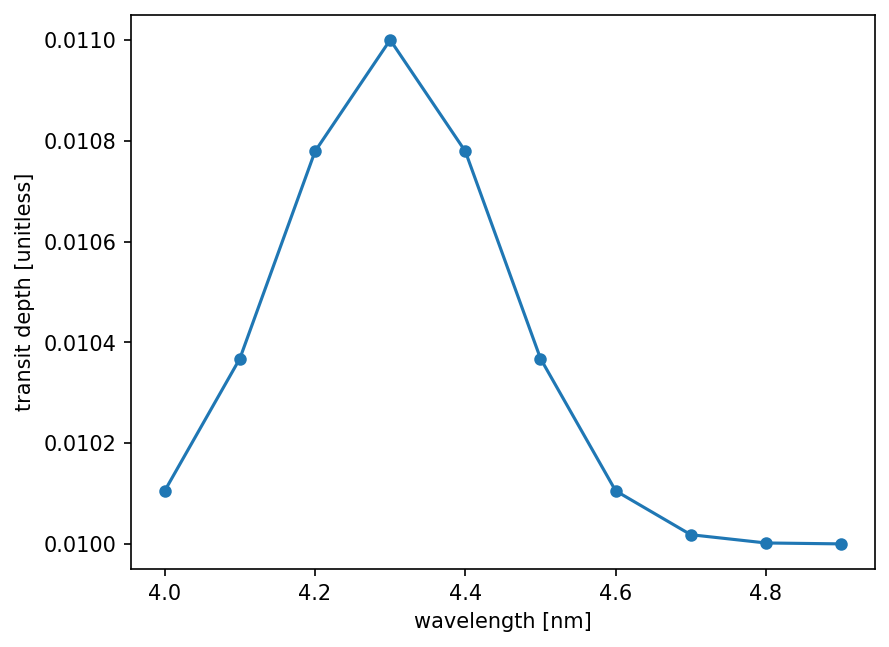

In [2]:
PERIOD = 10.0  # day
DURATION = 0.3  # day
T0 = 0.0  # day
B = 0.3  # impact parameter
U = np.array([0.4, 0.3])  # LDCs

num_lcs = 10
wavelengths = np.linspace(4.0, 4.9, num_lcs)

# Let's make the depth change for each spectroscopic light curve
DEPTHS = 0.01
DEPTHS += 1e-3 * np.exp(-(((wavelengths - 4.3) / 0.2) ** 2))

# Let's see what the theoretical transmission spectrum would look like
fig, ax = plt.subplots(dpi=150)
ax.plot(wavelengths, DEPTHS, marker=".", ms=10, ls="-")
ax.set_xlabel("wavelength [nm]", fontsize=10)
ax.set_ylabel("transit depth [unitless]", fontsize=10)

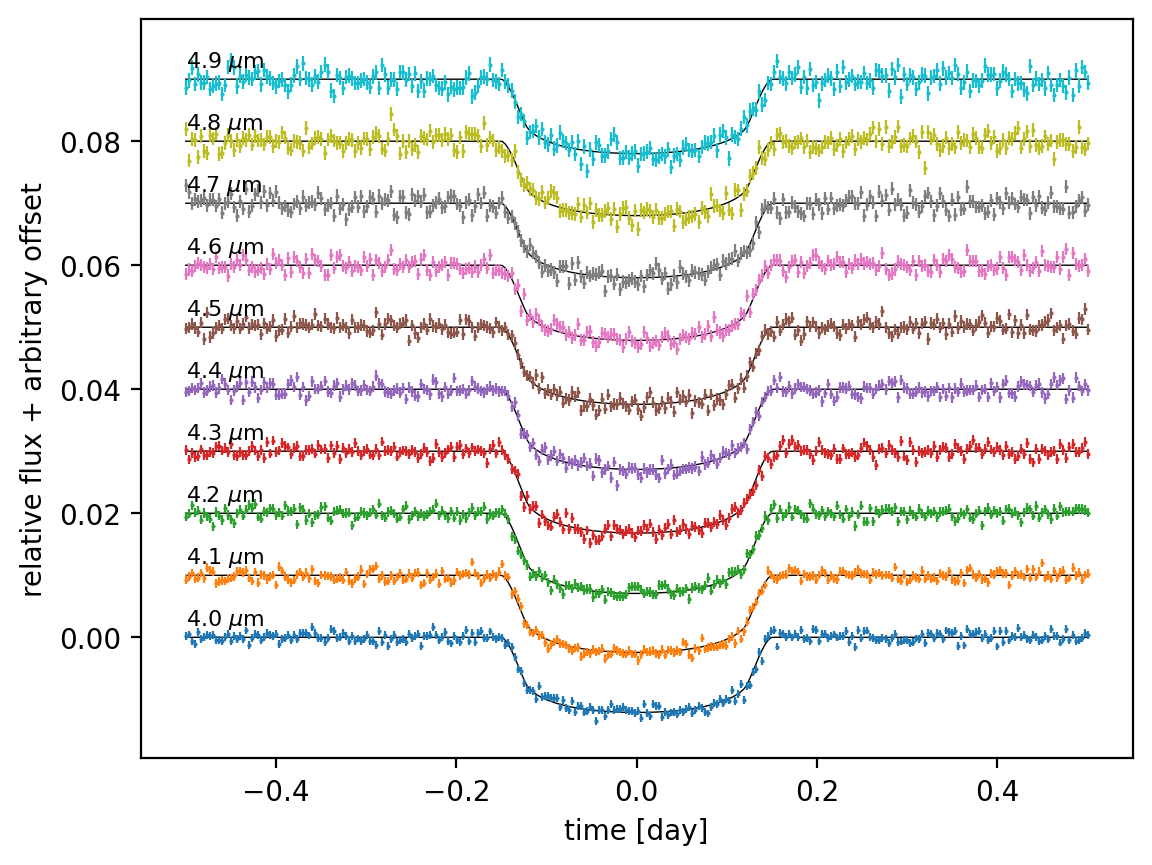

In [3]:
t = np.linspace(-0.5, 0.5, 300)
params = {
    "period": PERIOD,
    "duration": DURATION,
    "b": B,
    "t0": T0,
    "u": U,
    "rors": jnp.sqrt(DEPTHS),
}


def eval_limb_dark_light_curve(params, t):
    orbit = TransitOrbit(
        period=params["period"],
        duration=params["duration"],
        impact_param=params["b"],
        time_transit=params["t0"],
        radius_ratio=params["rors"],
    )
    return limb_dark_light_curve(orbit, params["u"])(t)


y_true = jax.vmap(
    eval_limb_dark_light_curve,
    in_axes=(
        {
            "period": None,
            "duration": None,
            "b": None,
            "t0": None,
            "u": None,
            "rors": 0,
        },
        None,
    ),
)(params, t)

stddevs = 1e-5 * wavelengths**3
yerr = np.repeat(stddevs, repeats=t.size).reshape(num_lcs, t.size)
keys = jax.random.split(jax.random.PRNGKey(99), num=stddevs.size)
dy = jax.vmap(
    lambda stddev, key: stddev * jax.random.normal(key, shape=(t.size,)), in_axes=(0, 0)
)(stddevs, keys)
y = y_true + dy

# Let's check our spectroscopic light curves
fig, ax = plt.subplots(dpi=200)
offset = 0.0
for _y_true, _y, stddev, wv in zip(y_true, y, stddevs, wavelengths):
    ax.plot(t, _y_true + offset, lw=0.5, color="k")
    ax.errorbar(
        t, _y + offset, yerr=stddev, marker=".", ms=1, ls="none", lw=0.8, capsize=0
    )
    ax.annotate(f"{wv:.1f} $\\mu$m", xy=(-0.5, 0.002 + offset), fontsize=8)
    offset += 0.01
_ = ax.set_xlabel("time [day]", fontsize=10)
_ = ax.set_ylabel("relative flux + arbitrary offset", fontsize=10)

## Setting up our Numpyro model

We'll follow a pretty similar setup for the numpyro model as the one we set up in the [single transit tutorial](transit.ipynb).

Let's also assume we have some informative priors from previous measurements that are relatively close to the true values for all the parameters besides the limb-darkening coefficients (LDCs). For those, we'll use the `QuadLDParams` distribution from the `numpyro_ext` package which implements the uninformative prior for quadratic LD as specified in [Kipping (2013)](https://doi.org/10.1093/mnras/stt1435).

In [4]:
def jitter_value(value, jitter_fraction, key):
    jitter = jitter_fraction * value * jax.random.normal(key)
    return value + jitter


# Priors
mu_duration = jitter_value(DURATION, 1e-3, jax.random.PRNGKey(8))
mu_t0 = jitter_value(T0, 1e-4, jax.random.PRNGKey(131))
mu_b = jitter_value(B, 1e-2, jax.random.PRNGKey(23))
keys = jax.random.split(jax.random.PRNGKey(55), num=num_lcs)
mu_depths = jax.vmap(jitter_value, in_axes=(0, None, 0))(DEPTHS, 1e-3, keys)

In [5]:
def model(t, yerr, y=None):
    num_lcs = jnp.atleast_2d(yerr).shape[0]

    # Priors

    ## Parameters shared across spectroscopic light curves
    logD = numpyro.sample("logD", dist.Normal(jnp.log(mu_duration), 1e-2))
    duration = numpyro.deterministic("duration", jnp.exp(logD))

    t0 = numpyro.sample(
        "t0", dist.Normal(mu_t0, 1e-3)
    )  # We usually have pretty good constraints on t0
    b = numpyro.sample(
        "b",
        dist.TruncatedNormal(mu_b, 0.1, low=0.0, high=1.0),
    )
    u = numpyro.sample("u", distx.QuadLDParams())

    ## Parameters for each light curve
    depths = numpyro.sample(
        "depths",
        dist.TruncatedNormal(
            mu_depths,
            1e-3 * jnp.ones_like(mu_depths),
            low=0.0,
            high=1.0,
        ),
    )
    rors = jnp.atleast_1d(numpyro.deterministic("rors", jnp.sqrt(depths)))

    params = {
        "period": PERIOD,
        "duration": duration,
        "t0": t0,
        "b": b,
        "u": u,
        "rors": rors,
    }

    y_model = jax.vmap(
        eval_limb_dark_light_curve,
        in_axes=(
            {
                "period": None,
                "duration": None,
                "b": None,
                "t0": None,
                "u": None,
                "rors": 0,
            },
            None,
        ),
    )(params, t)

    numpyro.sample("obs", dist.Normal(y_model, yerr), obs=y)

## Checking priors
Let's check our priors to:
1. Make sure the range of our priors are physically sensible, and
2. We're not *too* off from the true values

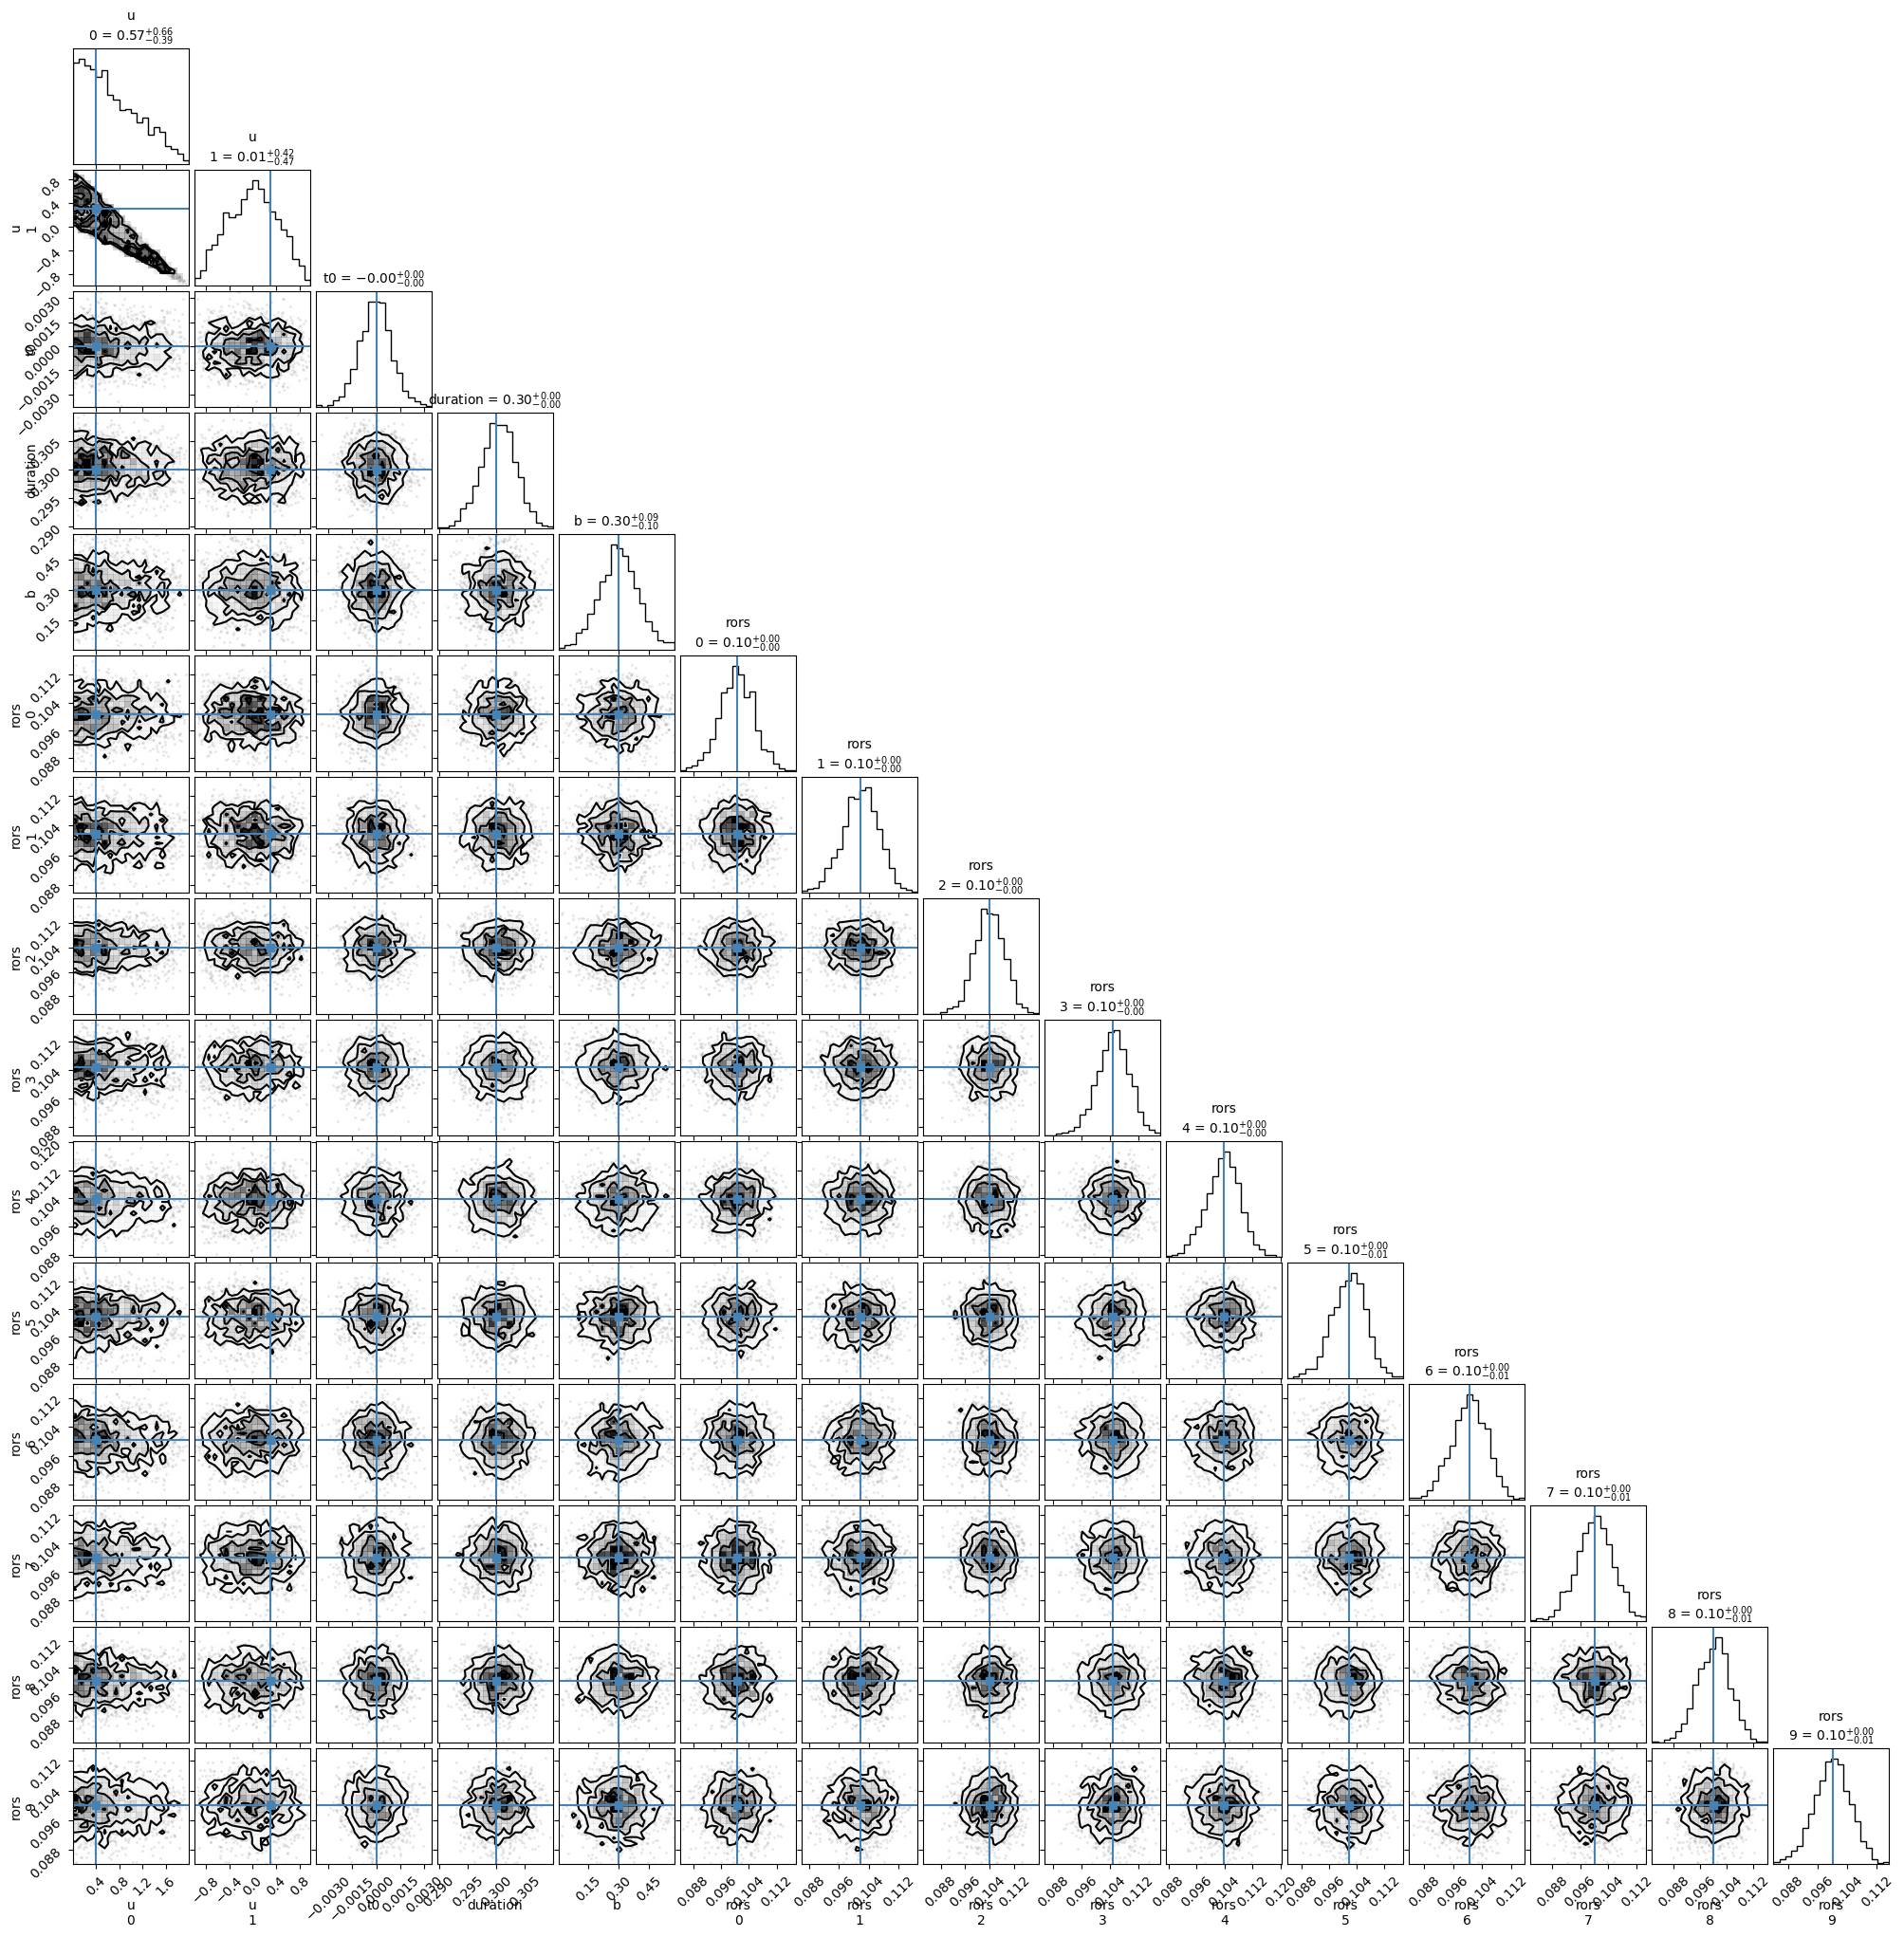

In [6]:
n_prior_samples = 2000
prior_samples = numpyro.infer.Predictive(model, num_samples=n_prior_samples)(
    jax.random.PRNGKey(0), t, yerr
)

# Let's make it into an arviz InferenceData object.
# To do so we'll first need to reshape the samples to be of shape (chains, draws, *shape)
converted_prior_samples = {
    "prior": {f"{p}": np.expand_dims(prior_samples[p], axis=0) for p in prior_samples}
}
prior_samples_inf_data = az.from_dict(converted_prior_samples)

# Plot the corner plot
fig = plt.figure(figsize=(20, 20))
_ = corner.corner(
    prior_samples_inf_data,
    fig=fig,
    group="prior",
    var_names=["u", "t0", "duration", "b", "rors"],
    truths=[*U, T0, DURATION, B, *jnp.sqrt(DEPTHS)],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 10},
)

## Optimize and get MAP estimate
Let's optimize the model to calculate the *maximum a posteriori* (MAP) estimate so that we can use it as the starting point for our MCMC run.

We've found the optimization to be more robust (i.e., not sensitive to the random seed) when we optimize the parameters in batches instead of all at once. 

In [7]:
init_params = {
    "period": PERIOD,
    "duration": mu_duration,
    "b": mu_b,
    "u": numpyro_ext.distributions.QuadLDParams().sample(jax.random.PRNGKey(2345)),
    "t0": mu_t0,
    "depths": mu_depths,
}

keys = jax.random.split(jax.random.PRNGKey(55), num=3)

soln = optimx.optimize(
    model,
    sites=["duration", "t0", "b"],
    start=init_params,
)(keys[0], t, yerr, y=y)

soln = optimx.optimize(
    model,
    sites=["depths", "u"],
    start=soln,
)(keys[1], t, yerr, y=y)

soln = optimx.optimize(
    model,
    start=soln,
)(keys[2], t, yerr, y=y)

Let's extract the model parameters from the `soln` dictionary and plot our MAP model

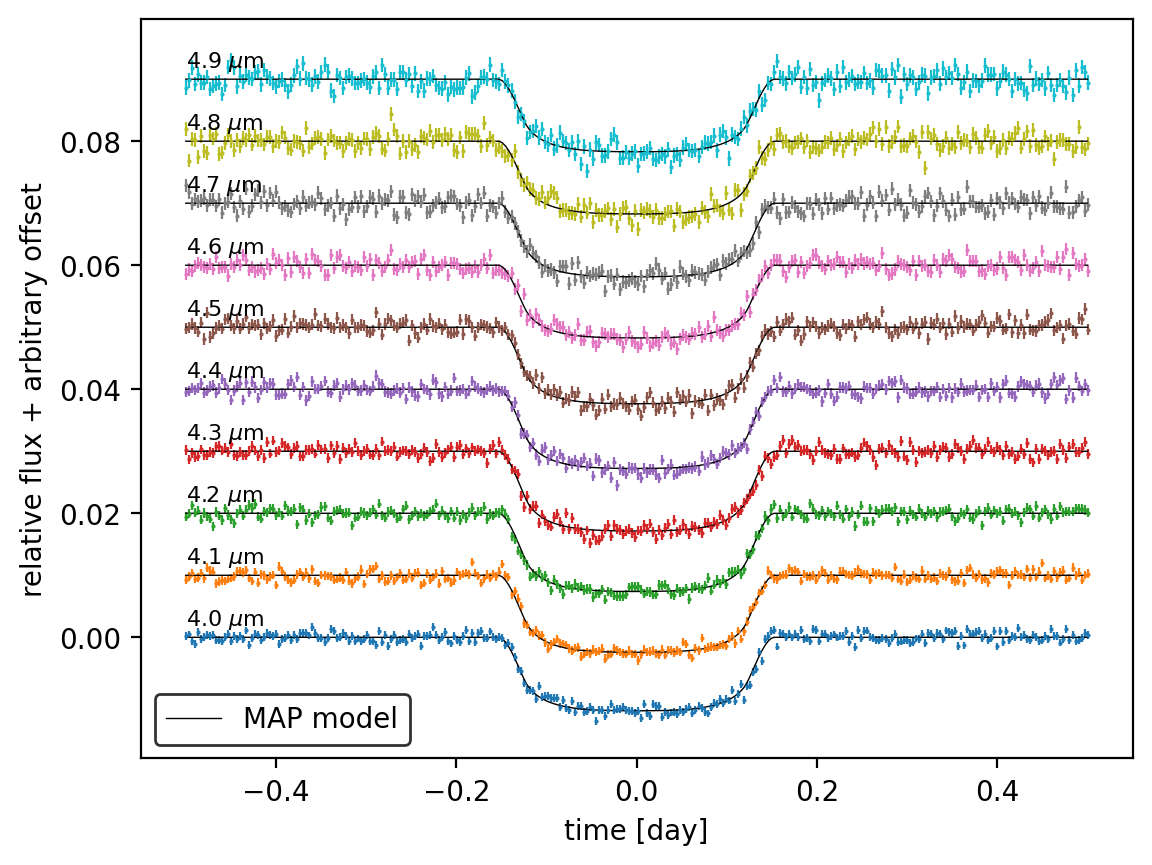

In [8]:
param_keys = [k for k in params.keys() if k != "period"]
map_params = {"period": PERIOD} | {"u": U} | {k: soln[k] for k in param_keys}

in_axes = {
    "period": None,
    "duration": None,
    "b": None,
    "t0": None,
    "u": None,
    "rors": 0,
}

y_model = jax.vmap(eval_limb_dark_light_curve, in_axes=(in_axes, None))(map_params, t)

fig, ax = plt.subplots(dpi=200)
offset = 0.0
_label = "MAP model"
for _y_model, _y, stddev, wv in zip(y_model, y, stddevs, wavelengths):
    ax.errorbar(
        t, _y + offset, yerr=stddev, marker=".", ms=1, ls="none", lw=0.8, capsize=0
    )
    ax.annotate(f"{wv:.1f} $\mu$m", xy=(-0.5, 0.002 + offset), fontsize=8)
    ax.plot(t, _y_model + offset, lw=0.5, color="k", label=_label)
    offset += 0.01
    _label = None
ax.set_xlabel("time [day]", fontsize=10)
ax.set_ylabel("relative flux + arbitrary offset", fontsize=10)
ax.legend(markerscale=2, edgecolor="k")

Let's see how these MAP values compare to the the true values.

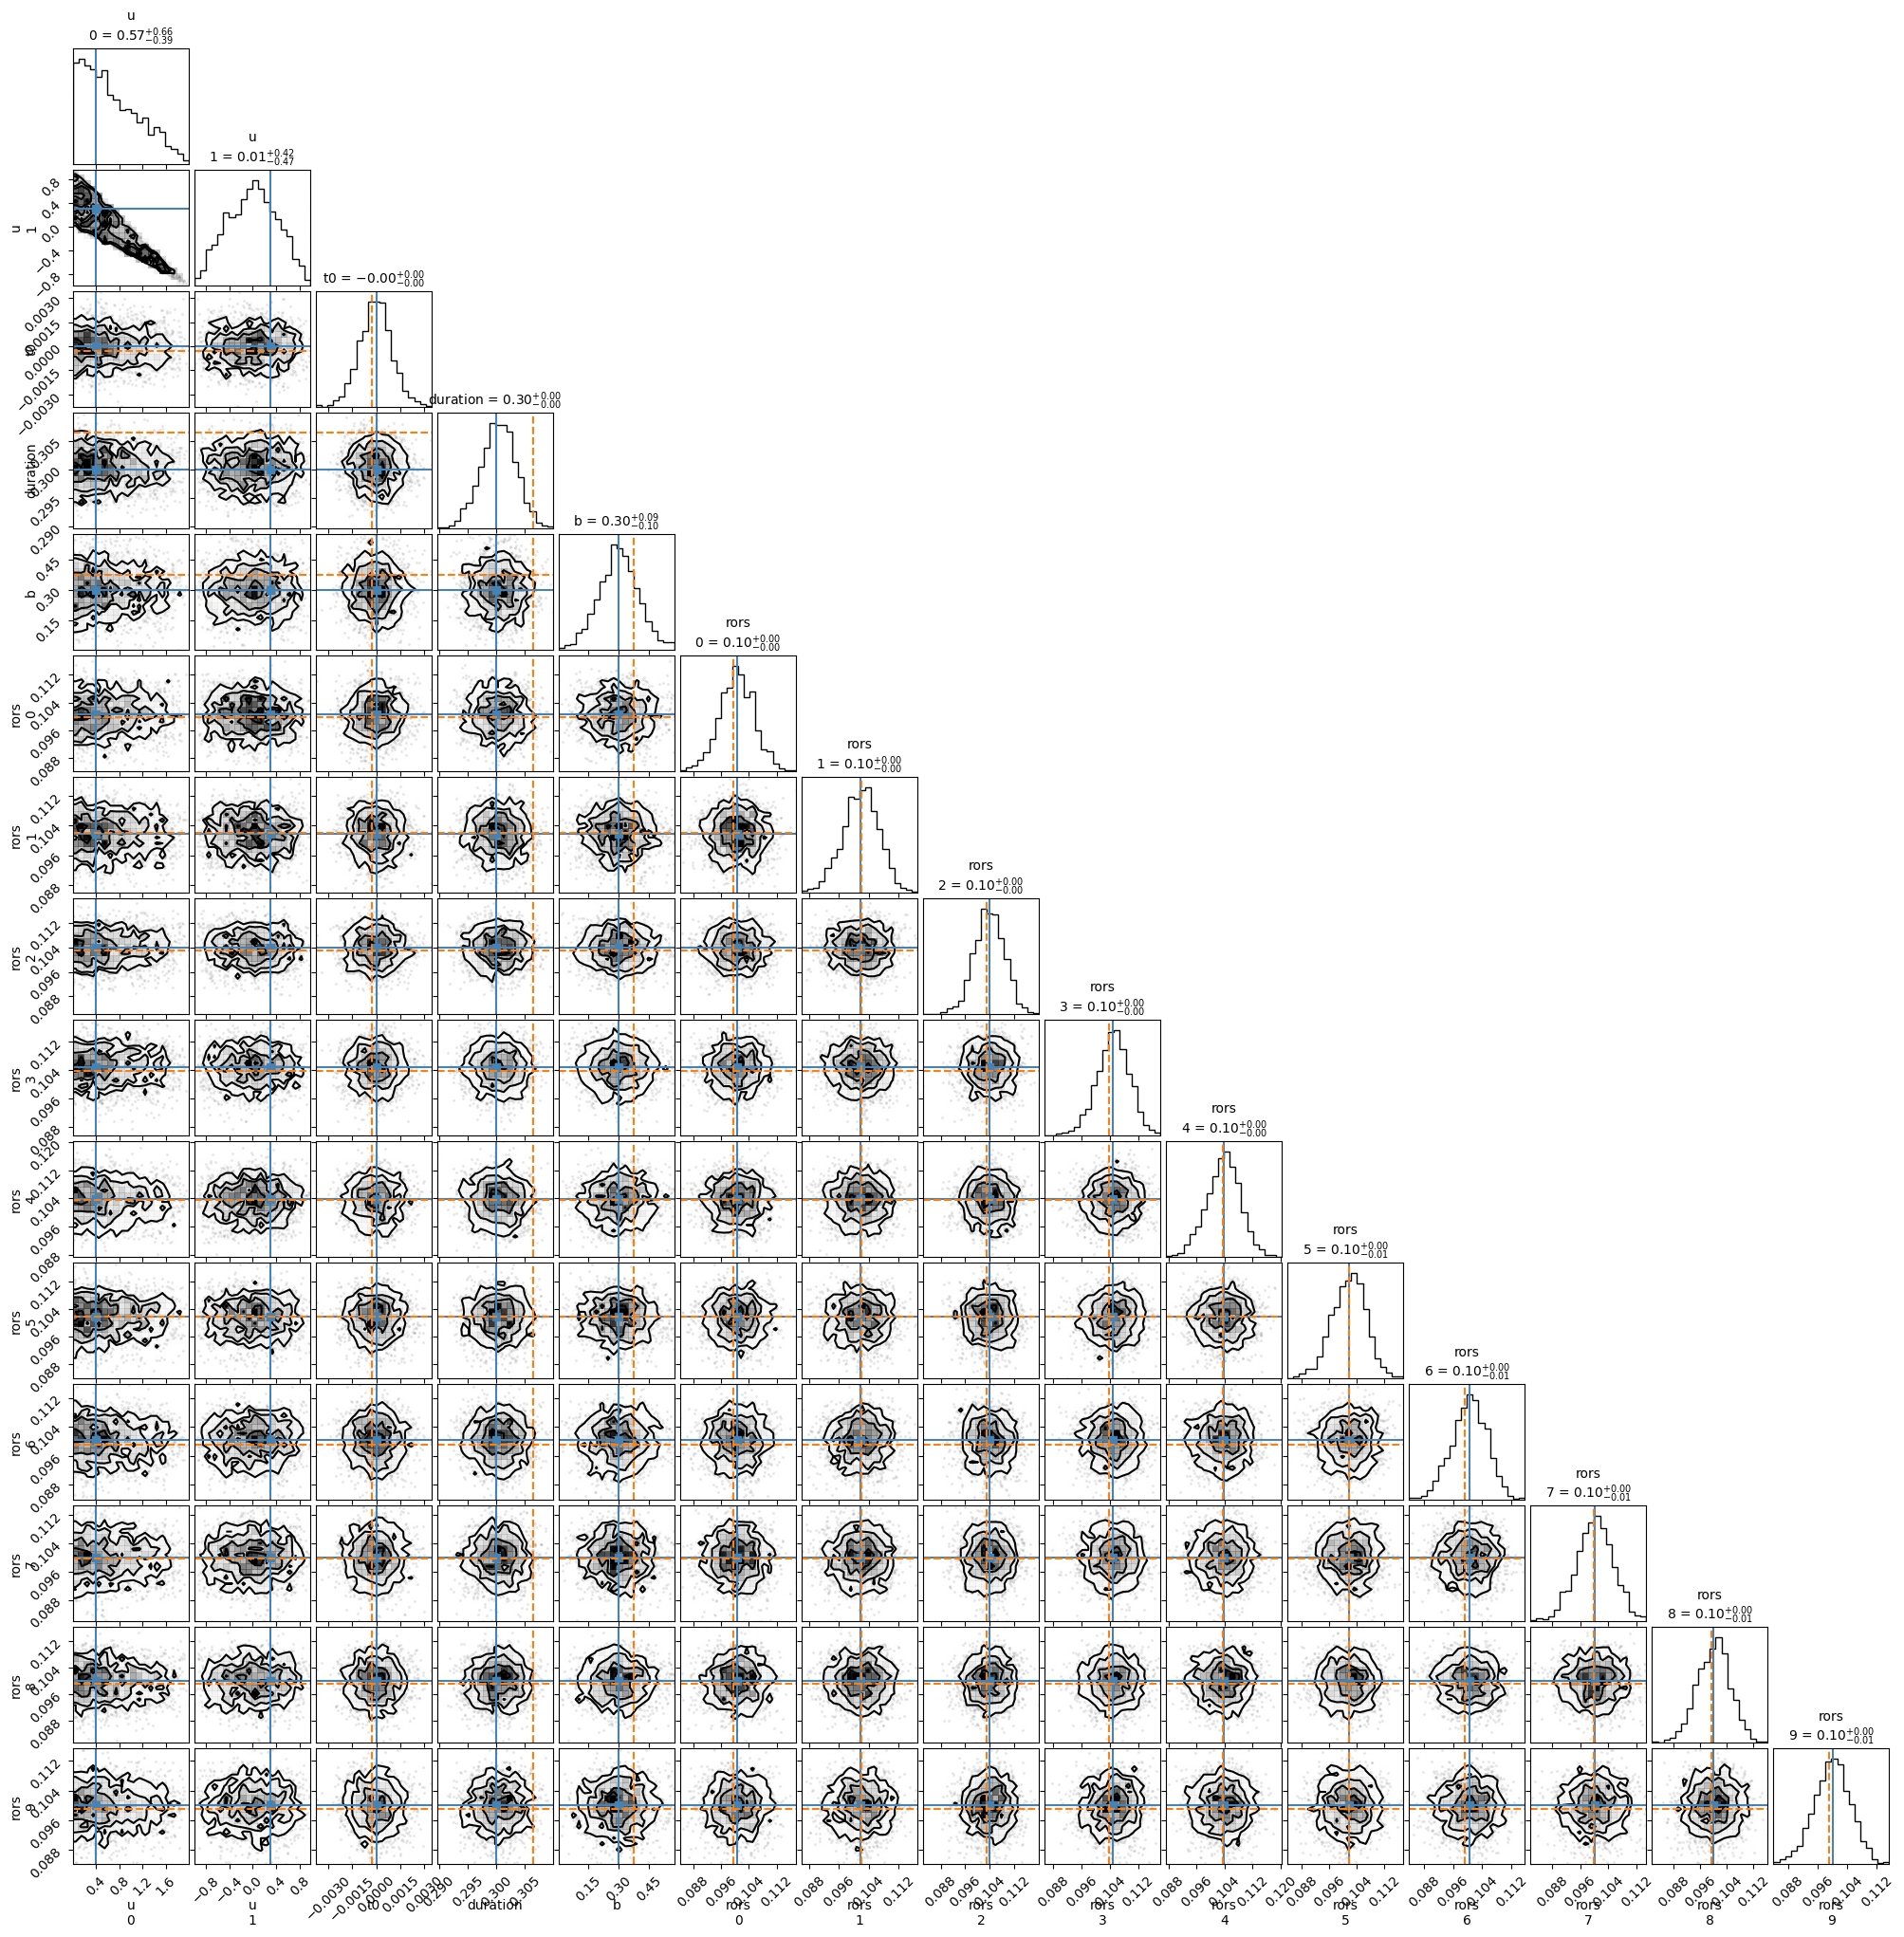

In [9]:
var_names = ["u", "t0", "duration", "b", "rors"]
map_params_ordered = [jnp.atleast_1d(map_params[k]) for k in var_names]
map_values_ordered = list(itertools.chain(*map_params_ordered))

fig = plt.figure(figsize=(20, 20))
fig = corner.corner(
    prior_samples_inf_data,
    group="prior",
    fig=fig,
    var_names=var_names,
    truths=[*U, T0, DURATION, B, *jnp.sqrt(DEPTHS)],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 10},
)

corner.overplot_lines(fig, map_values_ordered, color="C1", ls="--")

The MAP radius ratios are all higher than the true values but to different extents. <br>
Let's check how a transmission spectrum derived from just the MAP estimate would compare to the true one.

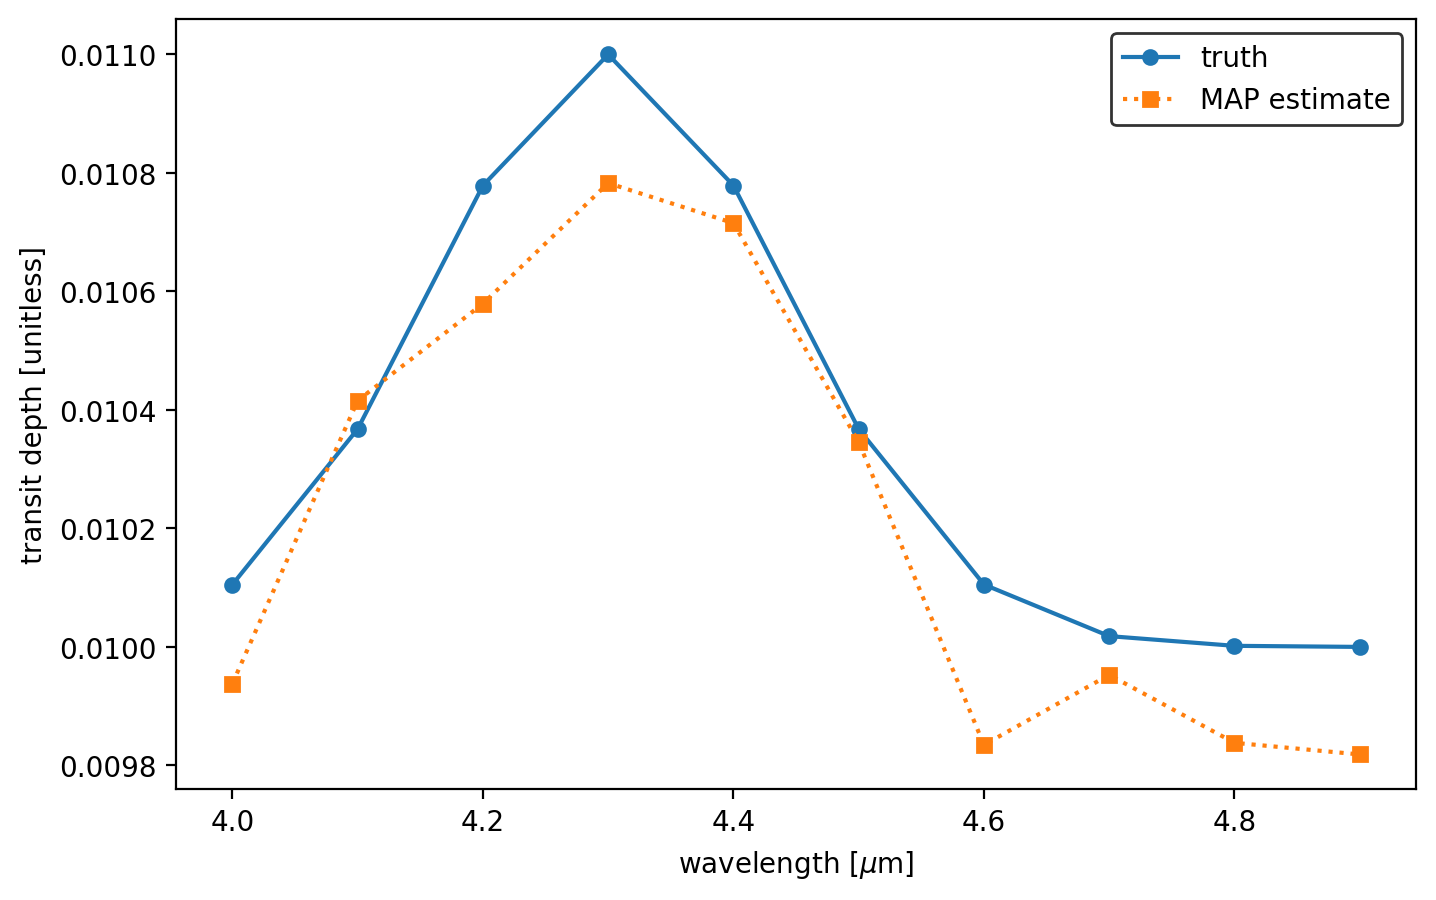

In [10]:
fig, ax = plt.subplots(dpi=200, figsize=(8, 5))
ax.plot(wavelengths, DEPTHS, marker=".", ms=10, ls="-", label="truth")
ax.plot(
    wavelengths, map_params["rors"] ** 2, marker="s", ms=5, ls=":", label="MAP estimate"
)

ax.set_xlabel("wavelength [$\mu$m]", fontsize=10)
ax.set_ylabel("transit depth [unitless]", fontsize=10)
ax.legend(edgecolor="k")

A constant offset would potentially be fine since we can fit for an overall vertical shift, but the fact that the shape is different isn't great. <br>
That being said, for a real observation you'd probably be running MCMC and plot the distribution of the posteriors. We'll cover how to do that in a subsequent tutorial.

## MCMC

In [24]:
sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(
        model,
        dense_mass=True,
        regularize_mass_matrix=True,
        init_strategy=numpyro.infer.init_to_value(values=map_params),
        ),
    num_warmup=1000,
    num_samples=2000,
    num_chains=2,
    progress_bar=True,
)

sampler.run(jax.random.PRNGKey(1), t, y=y, yerr=yerr)

Compiling.. :   0%|                                                                                                                                                                                 | 0/3000 [00:00<?, ?it/s]

In [25]:
sampler.print_summary()

Running chain 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [3:46:36<00:00,  4.53s/it]

Running chain 1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [4:53:13<00:00,  5.86s/it]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      0.67      0.30      0.70      0.35      0.98      1.00     20.45
 depths[0]      0.03      0.02      0.02      0.01      0.06      1.27      2.45
 depths[1]      0.03      0.02      0.02      0.01      0.06      1.37      2.10
 depths[2]      0.03      0.02      0.02      0.01      0.05      1.38      1.96
 depths[3]      0.03      0.02      0.02      0.01      0.05      1.30      2.02
 depths[4]      0.03      0.03      0.02      0.01      0.05      1.61      1.60
 depths[5]      0.03      0.02      0.02      0.01      0.04      1.43      1.76
 depths[6]      0.03      0.03      0.01      0.01      0.04      1.80      1.47
 depths[7]      0.02      0.03      0.01      0.01      0.02     10.40      1.09
 depths[8]      0.02      0.03      0.01      0.01      0.02      6.29      1.12
 depths[9]      0.02      0.02      0.01      0.01      0.03      2.22      1.32
      logD     -1.30      0